In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
plt.rcParams.update({'font.size': 13}) 

2026-05-03 20:52:51.364844: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Data Generation: Sine Curves

Generate **10,000 sine curves** of the form:

$$
x(t) = A \cdot \sin(\omega t + \phi)
$$

where the parameters are drawn from uniform distributions:

- Amplitude: $ A \sim \mathcal{U}[0.5, 1.5] $
- Frequency: $ \omega \sim \mathcal{U}[0.5, 2] $
- Phase: $ \phi \sim \mathcal{U}[0, 2\pi] $

Sample each curve at $N = 100$ equally spaced points over $t \in [0, 4\pi]$.
Your clean_curve array should have shape (10000, 100).

In [2]:
# generate dataset
num_curve=10000
A = np.random.uniform(0.5,1.5,size=(num_curve,1))
w = np.random.uniform(0.5,2,size=(num_curve,1))
phi = np.random.uniform(0,2*np.pi,size=(num_curve,1))

N = 100
t = np.linspace(0,4*np.pi,100)

clean_curve = A*np.sin(w*t + phi)
clean_curve.shape

(10000, 100)

## Add Gaussian Noise

$$
x_{\text{noisy}}(t) = x(t) + \epsilon, \qquad \epsilon \sim \mathcal{N}(0, \sigma^2), \quad \sigma = 0.2
$$
Your noisy_curve array should have shape (10000, 100).

In [3]:
# generate noisy data
sigma = 0.2
err = np.random.normal(loc=0, scale=sigma, size=clean_curve.shape)

noisy_curve = clean_curve + err
noisy_curve.shape

(10000, 100)

Plot examples showing the clean and noisy curve.

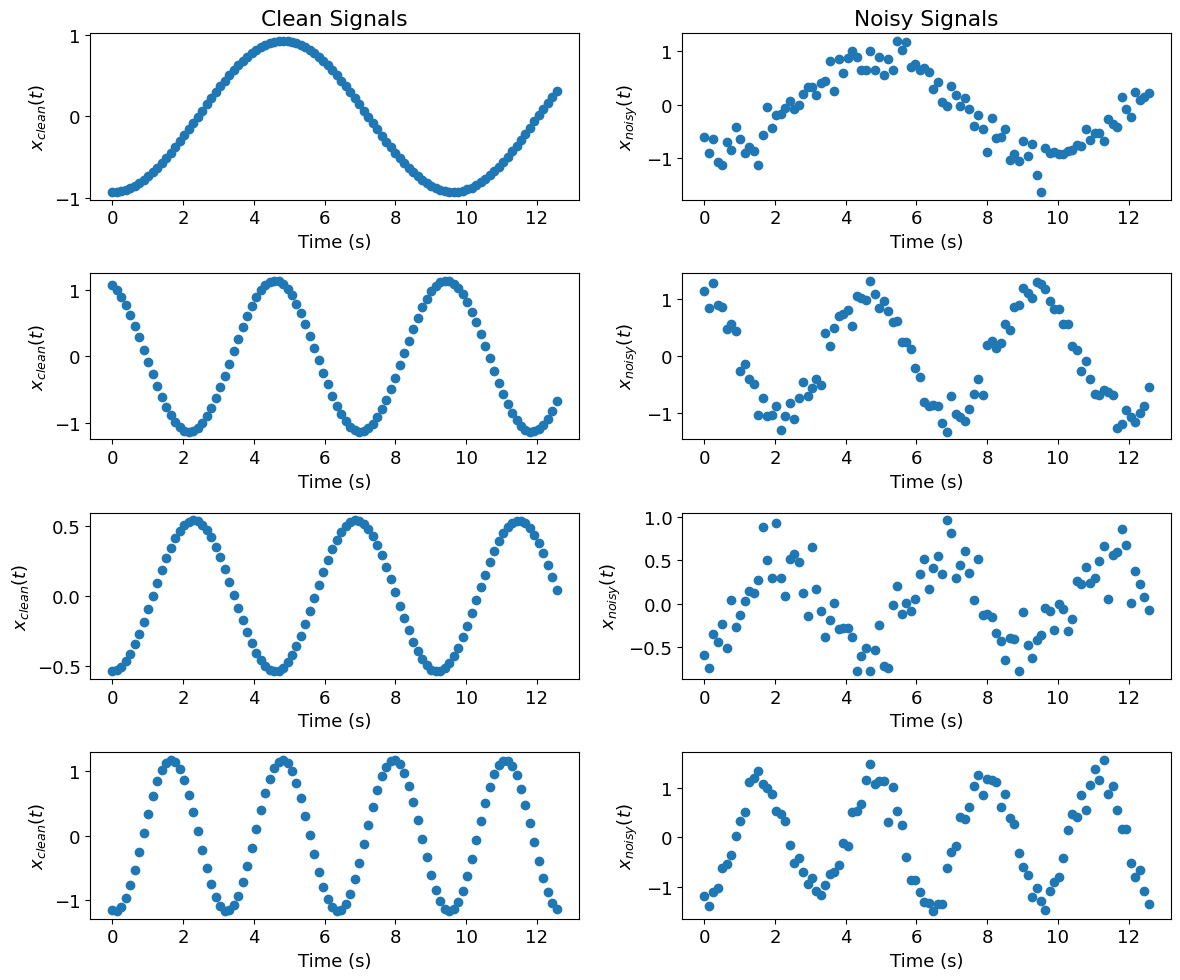

In [4]:
# plot clean vs noisy examples
fig, axes = plt.subplots(4, 2, figsize=(12, 10))
axes[0,0].scatter(t, clean_curve[3])
axes[0,1].scatter(t, noisy_curve[3])

axes[1,0].scatter(t, clean_curve[489])
axes[1,1].scatter(t, noisy_curve[489])

axes[2,0].scatter(t, clean_curve[1864])
axes[2,1].scatter(t, noisy_curve[1864])

axes[3,0].scatter(t, clean_curve[9999])
axes[3,1].scatter(t, noisy_curve[9999])

axes[0,0].set_title("Clean Signals")
axes[0,1].set_title("Noisy Signals")

for i in range(4):
    axes[i,0].set_ylabel(r"$x_{clean}(t)$")
    axes[i,1].set_ylabel(r"$x_{noisy}(t)$")
    
    axes[i,0].set_xlabel("Time (s)")
    axes[i,1].set_xlabel("Time (s)")

plt.tight_layout()
plt.savefig("clean_noisy4.png",dpi=300)
plt.show()

## Dataset Split

Split into **90% training / 10% validation**.
- **Input**  (noisy_curve) : X_train -> shape (9000, 100), X_val -> shape (1000, 100)
- **Target** (clean_curve): Y_train -> shape (9000, 100), Y_val -> shape (1000, 100)

In [5]:
# dataset split
#get a different index for different sine curves
idx = np.random.permutation(num_curve) #this will shuffle through different indices
training_size = int(num_curve*0.9) #90% training - must be integer for indexing
train_idx = idx[:training_size] #the 90% training set
#train_idx.shape
val_idx = idx[training_size:] #the remaning 1000 (10%)
#val_idx.shape

#input
x_train = noisy_curve[train_idx]
x_val = noisy_curve[val_idx]

#target
y_train = clean_curve[train_idx]
y_val = clean_curve[val_idx]

## Autoencoder Model

**Fully connected (dense) autoencoder**
- **Encoder** compresses the input into a low-dimensional **latent space**
- **Decoder** reconstructs the signal from the latent representation

The network is trained to minimise **mean squared error (MSE)** between the reconstructed and clean signal.

In [6]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(16, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,092 (58.95 KB)

 Trainable params: 15,092 (58.95 KB)

 Non-trainable params: 0 (0.00 B)

## Training with .fit()

.fit() trains the model. The key arguments are:

| Argument | What it means |
|---|---|
| X_train, Y_train | The data the model learns from |
| epochs | How many times the model sees the full training data |
| batch_size | How many samples to process before updating the weights |
| validation_data=(X_val, Y_val) | Data the model never trains on. It is used to check performance after each epoch |
| verbose=1 | Shows a progress bar while training; set to 0 to hide it |

After training, history stores the training loss and validation loss at every epoch:

If validation loss starts increasing while training loss keeps decreasing -> the model is **overfitting** (memorising the training data instead of generalising).

In [7]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3705 - val_loss: 0.1202
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0538 - val_loss: 0.0260
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0197 - val_loss: 0.0169
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0148 - val_loss: 0.0143
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0125 - val_loss: 0.0119
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0106 - val_loss: 0.0103
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0093 - val_loss: 0.0094
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0083 - val_loss: 0.0081
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0076 - val_loss: 0.0079
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0071 - val_loss: 0.0072
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0067 - val_loss: 0.0070
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0063 - val_lo

Plot the training and validation loss curves.

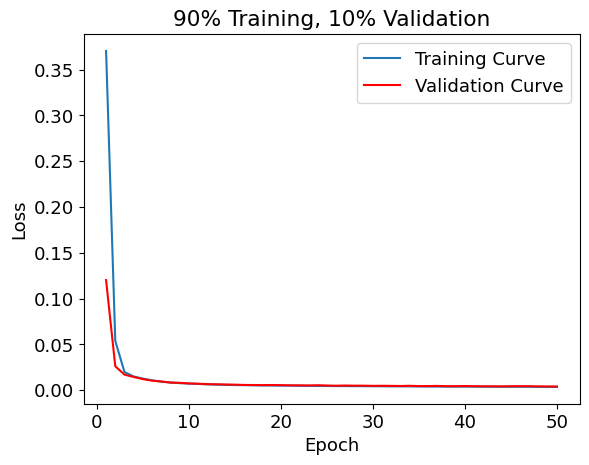

In [8]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.savefig("Loss_Curves.png",dpi=300)

## Making Predictions with .predict()

model.predict(X) passes the input array through the trained network and returns reconstructed outputs.

In [9]:
examples = [0, 1, 2, 3]

reconstructed_y = autoencoder.predict(x_val[examples]) # Returns shape (4, 100)
reconstructed_y.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


(4, 100)

Plot the clean signal, noisy input, and reconstructed signal.

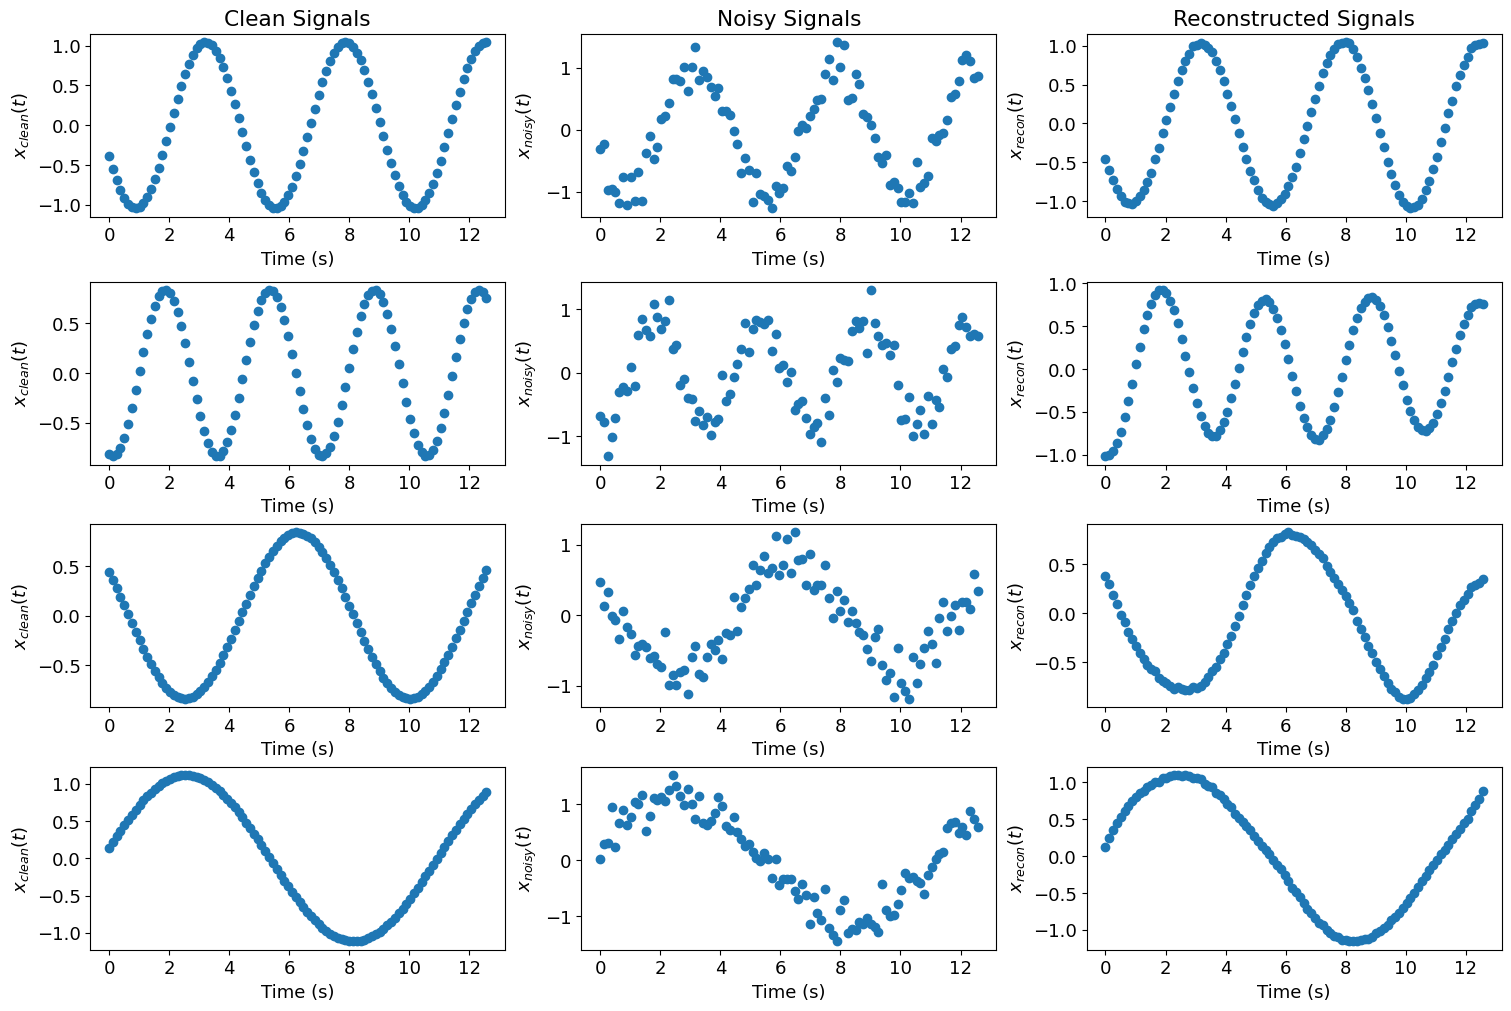

In [10]:
# plot clean vs noisy examples
fig, axes = plt.subplots(4, 3, figsize=(15, 10),constrained_layout=True)
for i, idx in enumerate(examples):
    axes[i,0].scatter(t,y_val[idx]) #clean
    axes[i,1].scatter(t,x_val[idx]) #noisy
    axes[i,2].scatter(t,reconstructed_y[idx]) #reconstructed
axes[0,0].set_title("Clean Signals")
axes[0,1].set_title("Noisy Signals")
axes[0,2].set_title("Reconstructed Signals")

for i in range(4):
    axes[i,0].set_ylabel(r"$x_{clean}(t)$")
    axes[i,1].set_ylabel(r"$x_{noisy}(t)$")
    axes[i,2].set_ylabel(r"$x_{recon}(t)$")
    
    axes[i,0].set_xlabel("Time (s)")
    axes[i,1].set_xlabel("Time (s)")
    axes[i,2].set_xlabel("Time (s)")

plt.savefig("reconstructed.png",dpi=300)
plt.show()

# Parameter Exploration
Investigate how performance changes when modifying the following parameters. For each experiment, provide plots of training and validation loss vs. epochs. Also report the architecture and comment on whether training converges and whether you observe overfitting.

## Training data size 
- 90% training , 10% validation (baseline)
- 60% training , 40% validation
- 30% training , 70% validation
  
Discuss the effect on validation MSE and overfitting.

In [11]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(16, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,092 (58.95 KB)

 Trainable params: 15,092 (58.95 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# dataset split
#get a different index for different sine curves
idx = np.random.permutation(num_curve) #this will shuffle through different indices
training_size = int(num_curve*0.9) #90% training - must be integer for indexing
train_idx = idx[:training_size] #the 90% training set
#train_idx.shape
val_idx = idx[training_size:] #the remaning 1000 (10%)
#val_idx.shape

#input
x_train = noisy_curve[train_idx]
x_val = noisy_curve[val_idx]

#target
y_train = clean_curve[train_idx]
y_val = clean_curve[val_idx]

In [13]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3626 - val_loss: 0.1271
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0601 - val_loss: 0.0309
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0220 - val_loss: 0.0176
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0153 - val_loss: 0.0145
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0123 - val_loss: 0.0113
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0101 - val_loss: 0.0095
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0088 - val_loss: 0.0086
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0080 - val_loss: 0.0078
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0073 - val_loss: 0.0072
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0068 - val_loss: 0.0071
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0064 - val_loss: 0.0065
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0060 - val_lo

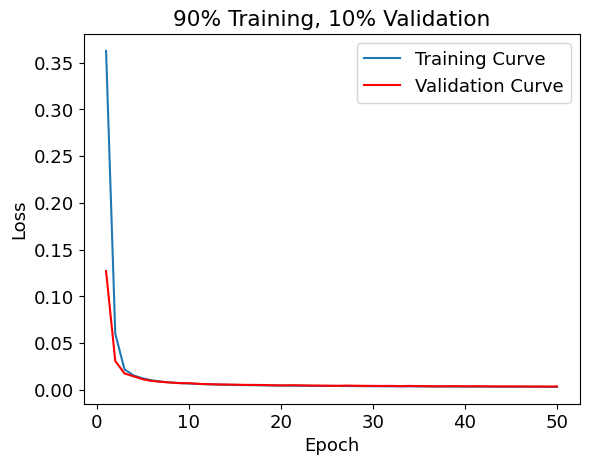

In [14]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.savefig("Loss_Curves9010.png",dpi=300)

In [15]:
# dataset split
#get a different index for different sine curves
idx = np.random.permutation(num_curve) #this will shuffle through different indices
training_size = int(num_curve*0.6) #60% training - must be integer for indexing
train_idx = idx[:training_size] #the 60% training set
#train_idx.shape
val_idx = idx[training_size:] #the remaning 1000 (10%)
#val_idx.shape

#input
x_train = noisy_curve[train_idx]
x_val = noisy_curve[val_idx]

#target
y_train = clean_curve[train_idx]
y_val = clean_curve[val_idx]

In [16]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0033 - val_loss: 0.0033
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0032 - val_loss: 0.0033
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0032 - val_loss: 0.0032
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0031 - val_loss: 0.0033
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0031 - val_loss: 0.0031
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0031 - val_loss: 0.0032
Epoch 7/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0031 - val_loss: 0.0032
Epoch 8/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0030 - val_loss: 0.0032
Epoch 9/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0030 - val_loss: 0.0032
Epoch 10/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0030 - val_loss: 0.0032
Epoch 11/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0030 - val_loss: 0.0033
Epoch 12/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0030 - val_lo

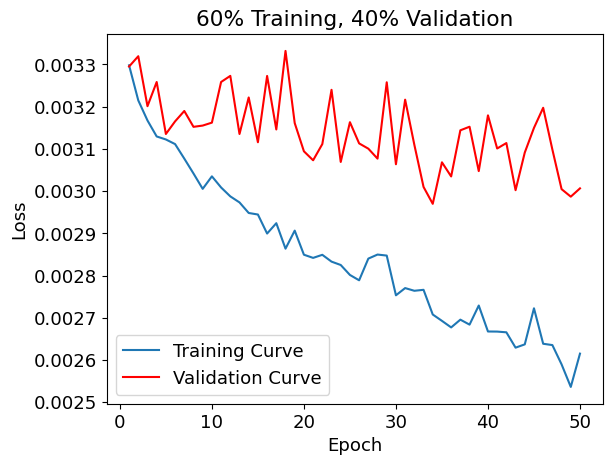

In [17]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("60% Training, 40% Validation")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.savefig("Loss_Curves6040.png",dpi=300)

In [18]:
# dataset split
#get a different index for different sine curves
idx = np.random.permutation(num_curve) #this will shuffle through different indices
training_size = int(num_curve*0.3) #70% training - must be integer for indexing
train_idx = idx[:training_size] #the 90% training set
#train_idx.shape
val_idx = idx[training_size:] #the remaning 1000 (10%)
#val_idx.shape

#input
x_train = noisy_curve[train_idx]
x_val = noisy_curve[val_idx]

#target
y_train = clean_curve[train_idx]
y_val = clean_curve[val_idx]

In [19]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0028 - val_loss: 0.0029
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0028 - val_loss: 0.0030
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0028 - val_loss: 0.0027
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0027 - val_loss: 0.0028
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0027 - val_loss: 0.0028
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0027 - val_loss: 0.0027
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0026 - val_loss: 0.0029
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0026 - val_loss: 0.0028
Epoch 9/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0026 - val_loss: 0.0028
Epoch 10/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0026 - val_loss: 0.0028
Epoch 11/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0025 - val_loss: 0.0029
Epoch 12/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0026 - val_l

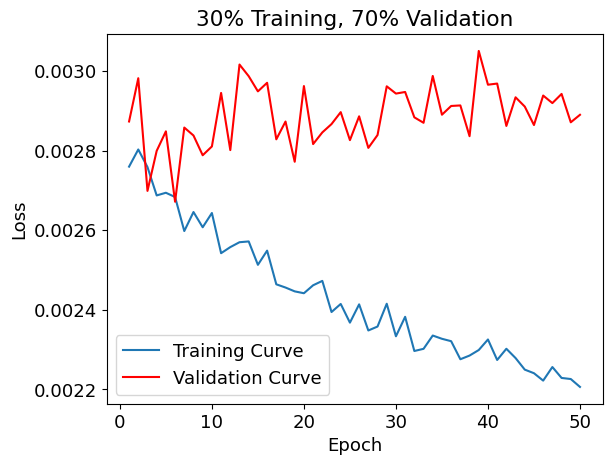

In [20]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("30% Training, 70% Validation")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.savefig("Loss_Curves3070.png",dpi=300)

## Network architecture
Fix the bottleneck at 4 and experiment with different numbers of layers and neurons.

For example:

Model 1 (Baseline): $100 \rightarrow 64 \rightarrow 4 \rightarrow 64 \rightarrow 100$

Model 2 : $100 \rightarrow 80 \rightarrow 40 \rightarrow 4 \rightarrow 40 \rightarrow 80 \rightarrow 100$

Model 3 : $100 \rightarrow 64 \rightarrow 32 \rightarrow 16 \rightarrow 4 \rightarrow 16 \rightarrow 32 \rightarrow 64 \rightarrow 100$

Record the training time and final validation MSE for each architecture.

In [21]:
#Continue using the 90%/10% for this
# dataset split
#get a different index for different sine curves
idx = np.random.permutation(num_curve) #this will shuffle through different indices
training_size = int(num_curve*0.9) #90% training - must be integer for indexing
train_idx = idx[:training_size] #the 90% training set
#train_idx.shape
val_idx = idx[training_size:] #the remaning 1000 (10%)
#val_idx.shape

#input
x_train = noisy_curve[train_idx]
x_val = noisy_curve[val_idx]

#target
y_train = clean_curve[train_idx]
y_val = clean_curve[val_idx]

In [22]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(16, activation='relu'), 
    Dense(4, activation='relu'),  # latent (bottleneck) layer
    Dense(16, activation='relu'),  
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,240 (59.53 KB)

 Trainable params: 15,240 (59.53 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
start = time.time()
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)
print(f"Elapsed: {time.time() - start:.4f} seconds")
# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)
print(f"Final validation MSE: {val_loss[-1]}")

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4800 - val_loss: 0.3922
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3298 - val_loss: 0.2715
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2325 - val_loss: 0.1939
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1679 - val_loss: 0.1382
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1224 - val_loss: 0.1027
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0903 - val_loss: 0.0822
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0712 - val_loss: 0.0674
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0584 - val_loss: 0.0570
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0495 - val_loss: 0.0499
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0429 - val_loss: 0.0453
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0387 - val_loss: 0.0414
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0344 - val_lo

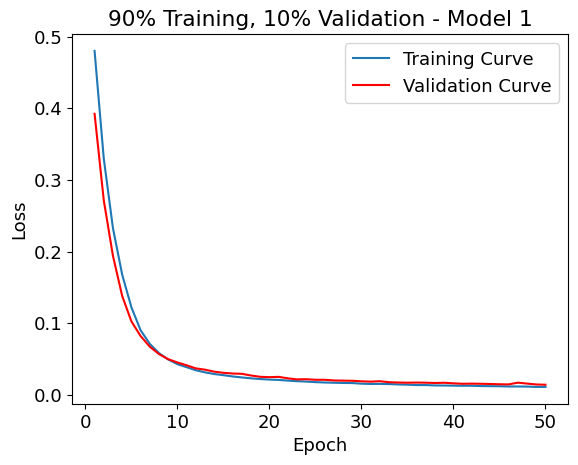

In [24]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Model 1")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.savefig("Loss_Curves_m1.png",dpi=300)

In [25]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(80, activation='relu'),
    Dense(40, activation='relu'),
    Dense(4, activation='relu'),  # latent (bottleneck) layer
    Dense(40, activation='relu'),
    Dense(80, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 80)             │         8,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 40)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 4)              │           164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 40)             │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 80)             │         3,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 100)            │         8,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,064 (90.09 KB)

 Trainable params: 23,064 (90.09 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
start = time.time()
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)
print(f"Elapsed: {time.time() - start:.4f} seconds")
# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)
print(f"Final validation MSE: {val_loss[-1]}")

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.4195 - val_loss: 0.2575
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1980 - val_loss: 0.1521
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1300 - val_loss: 0.0964
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0856 - val_loss: 0.0687
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0634 - val_loss: 0.0498
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0475 - val_loss: 0.0418
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0385 - val_loss: 0.0321
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0322 - val_loss: 0.0261
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0279 - val_loss: 0.0234
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0251 - val_loss: 0.0218
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0224 - val_loss: 0.0203
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0205 - val_lo

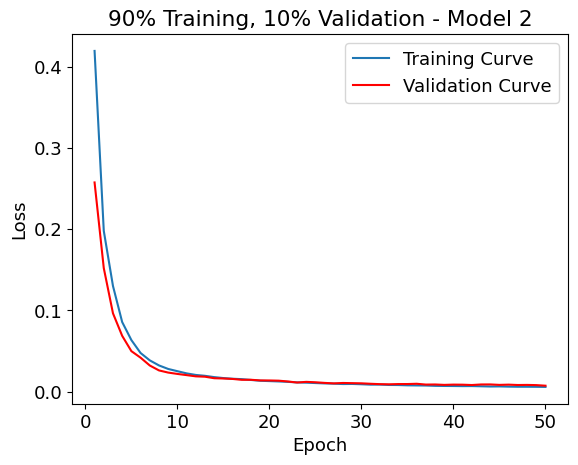

In [27]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Model 2")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.savefig("Loss_Curves_m2.png",dpi=300)

In [28]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(4, activation='relu'),  # latent (bottleneck) layer
    Dense(16, activation='relu'),
    Dense(32, activation='relu'),
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 4)              │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,376 (71.78 KB)

 Trainable params: 18,376 (71.78 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
start = time.time()
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)
print(f"Elapsed: {time.time() - start:.4f} seconds")
# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)
print(f"Final validation MSE: {val_loss[-1]}")

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.4864 - val_loss: 0.3778
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3267 - val_loss: 0.2667
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2461 - val_loss: 0.2221
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2049 - val_loss: 0.1926
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1669 - val_loss: 0.1495
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1286 - val_loss: 0.1170
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1049 - val_loss: 0.0980
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0896 - val_loss: 0.0837
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0773 - val_loss: 0.0729
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0660 - val_loss: 0.0644
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0586 - val_loss: 0.0584
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0525 - val_lo

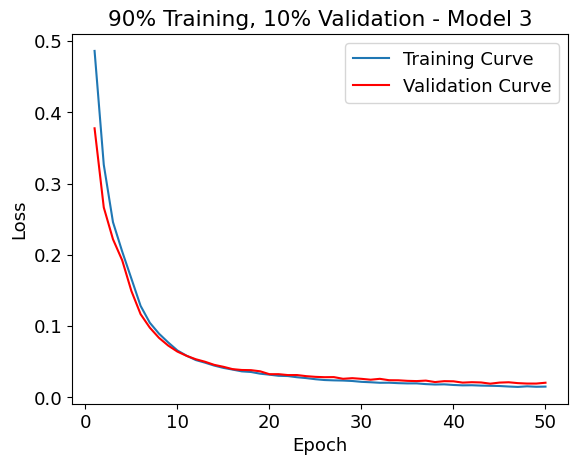

In [30]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Model 3")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.savefig("Loss_Curves_m3.png",dpi=300)

## Bottleneck Size
Fix the outer architecture (N$ \rightarrow 64 \rightarrow · \rightarrow 64 \rightarrow $N) and vary the bottleneck dimension: 16, 8, 4, 3, 2, 1. Determine the smallest bottleneck size that still reconstructs the signal accurately.

In [31]:
# dataset split
#get a different index for different sine curves
idx = np.random.permutation(num_curve) #this will shuffle through different indices
training_size = int(num_curve*0.9) #90% training - must be integer for indexing
train_idx = idx[:training_size] #the 90% training set
#train_idx.shape
val_idx = idx[training_size:] #the remaning 1000 (10%)
#val_idx.shape

#input
x_train = noisy_curve[train_idx]
x_val = noisy_curve[val_idx]

#target
y_train = clean_curve[train_idx]
y_val = clean_curve[val_idx]

In [32]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(16, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,092 (58.95 KB)

 Trainable params: 15,092 (58.95 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4052 - val_loss: 0.1686
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0740 - val_loss: 0.0352
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0231 - val_loss: 0.0186
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0159 - val_loss: 0.0158
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0137 - val_loss: 0.0137
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0120 - val_loss: 0.0120
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0106 - val_loss: 0.0108
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0094 - val_loss: 0.0097
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0084 - val_loss: 0.0085
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0077 - val_loss: 0.0081
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0072 - val_loss: 0.0075
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0069 - val_lo

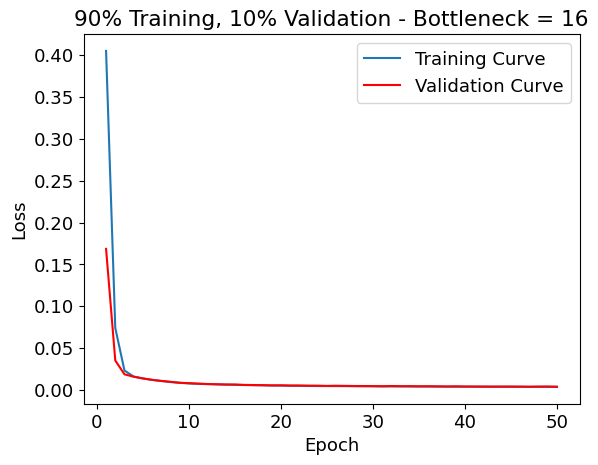

In [34]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Bottleneck = 16")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.savefig("Loss_Curves_b16.png",dpi=300)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


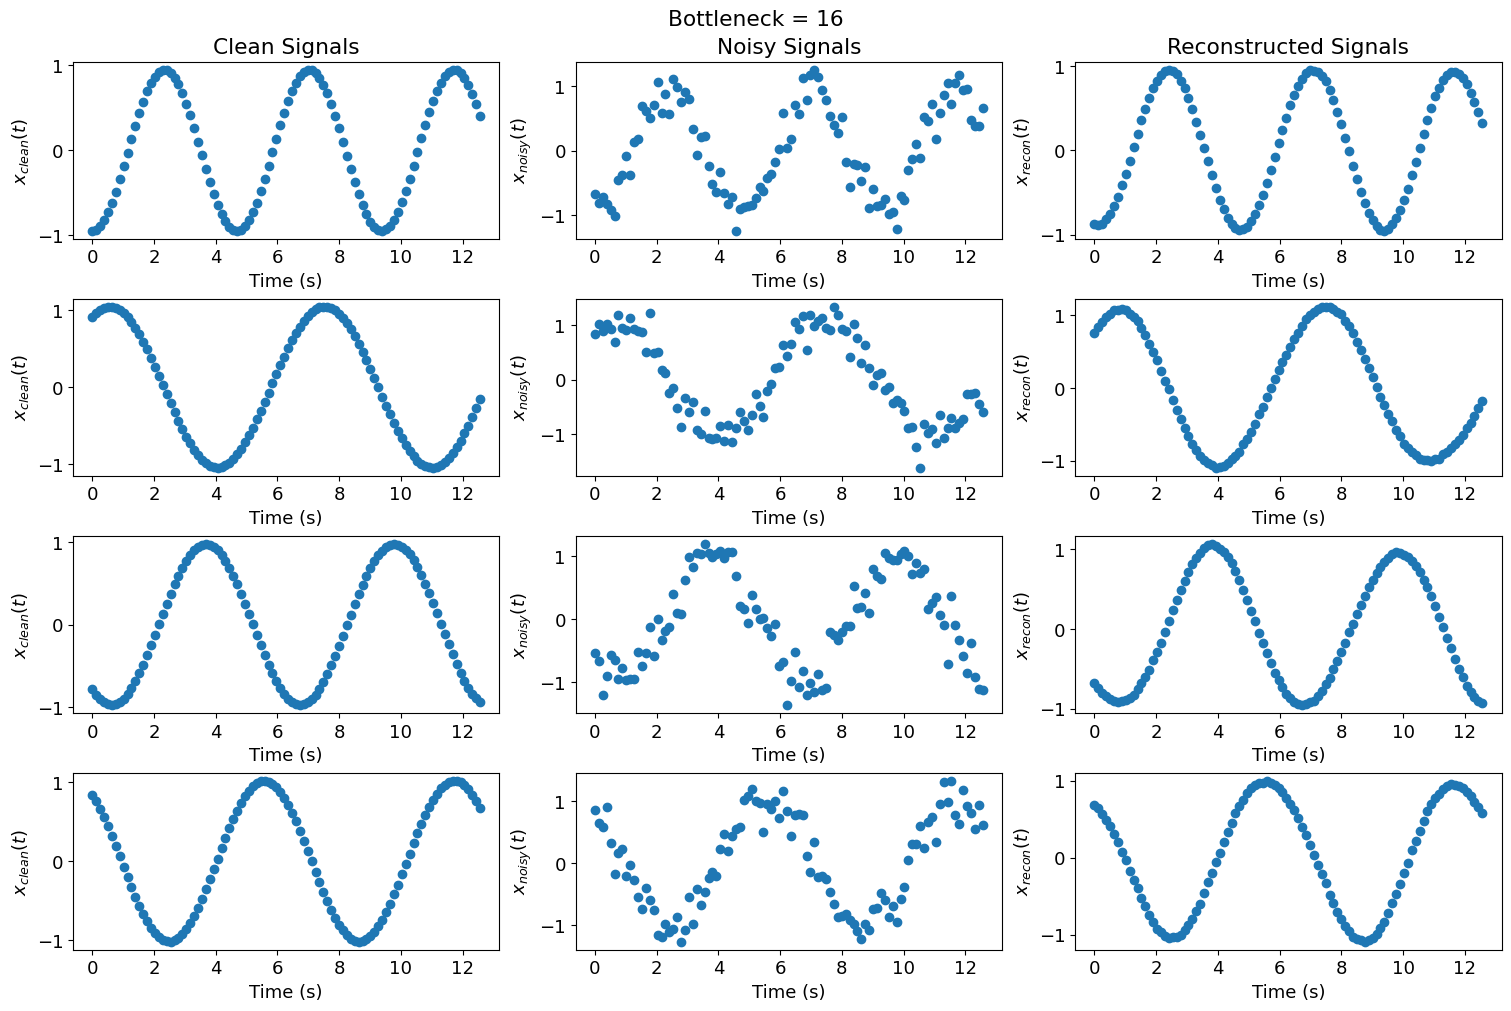

In [35]:
examples = [0, 1, 2, 3]

reconstructed_y = autoencoder.predict(x_val[examples]) # Returns shape (4, 100)
# plot clean vs noisy examples
fig, axes = plt.subplots(4, 3, figsize=(15, 10),constrained_layout=True)
for i, idx in enumerate(examples):
    axes[i,0].scatter(t,y_val[idx]) #clean
    axes[i,1].scatter(t,x_val[idx]) #noisy
    axes[i,2].scatter(t,reconstructed_y[idx]) #reconstructed
axes[0,0].set_title("Clean Signals")
axes[0,1].set_title("Noisy Signals")
axes[0,2].set_title("Reconstructed Signals")
fig.suptitle('Bottleneck = 16')

for i in range(4):
    axes[i,0].set_ylabel(r"$x_{clean}(t)$")
    axes[i,1].set_ylabel(r"$x_{noisy}(t)$")
    axes[i,2].set_ylabel(r"$x_{recon}(t)$")
    
    axes[i,0].set_xlabel("Time (s)")
    axes[i,1].set_xlabel("Time (s)")
    axes[i,2].set_xlabel("Time (s)")

plt.savefig("reconstruct_b16.png",dpi=300)
plt.show()

In [36]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(8, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,060 (54.92 KB)

 Trainable params: 14,060 (54.92 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4120 - val_loss: 0.2352
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1196 - val_loss: 0.0701
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0572 - val_loss: 0.0519
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0420 - val_loss: 0.0391
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0331 - val_loss: 0.0336
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0281 - val_loss: 0.0269
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0213 - val_loss: 0.0196
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0154 - val_loss: 0.0152
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0130 - val_loss: 0.0132
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0117 - val_loss: 0.0122
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0108 - val_loss: 0.0116
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0101 - val_lo

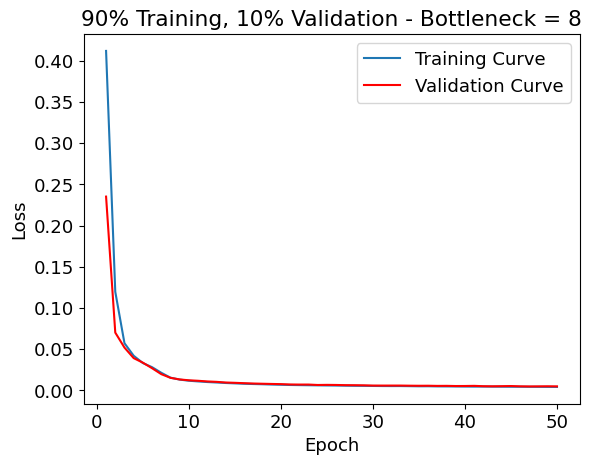

In [38]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Bottleneck = 8")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.savefig("Loss_Curves_b8.png",dpi=300)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


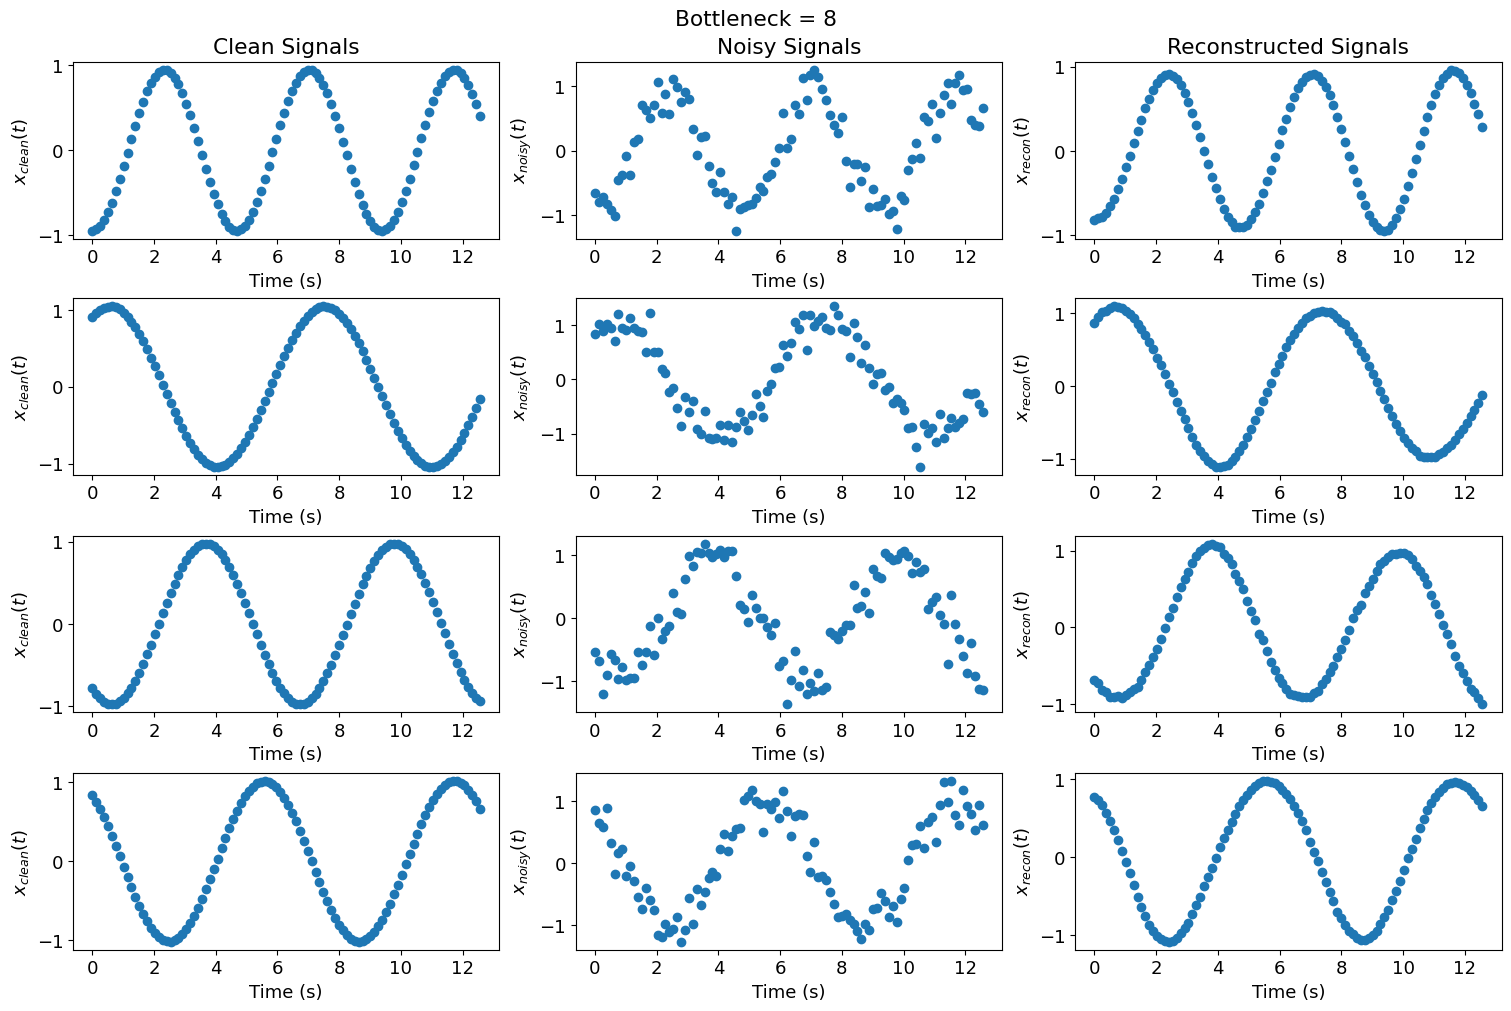

In [39]:
examples = [0, 1, 2, 3]

reconstructed_y = autoencoder.predict(x_val[examples]) # Returns shape (4, 100)
# plot clean vs noisy examples
fig, axes = plt.subplots(4, 3, figsize=(15, 10),constrained_layout=True)
for i, idx in enumerate(examples):
    axes[i,0].scatter(t,y_val[idx]) #clean
    axes[i,1].scatter(t,x_val[idx]) #noisy
    axes[i,2].scatter(t,reconstructed_y[idx]) #reconstructed
axes[0,0].set_title("Clean Signals")
axes[0,1].set_title("Noisy Signals")
axes[0,2].set_title("Reconstructed Signals")
fig.suptitle('Bottleneck = 8')
for i in range(4):
    axes[i,0].set_ylabel(r"$x_{clean}(t)$")
    axes[i,1].set_ylabel(r"$x_{noisy}(t)$")
    axes[i,2].set_ylabel(r"$x_{recon}(t)$")
    
    axes[i,0].set_xlabel("Time (s)")
    axes[i,1].set_xlabel("Time (s)")
    axes[i,2].set_xlabel("Time (s)")

plt.savefig("reconstruct_b8.png",dpi=300)
plt.show()

In [40]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(4, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 4)              │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,544 (52.91 KB)

 Trainable params: 13,544 (52.91 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.4497 - val_loss: 0.3227
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2602 - val_loss: 0.2273
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2073 - val_loss: 0.1935
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1716 - val_loss: 0.1577
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1400 - val_loss: 0.1337
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1183 - val_loss: 0.1143
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0996 - val_loss: 0.0976
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0839 - val_loss: 0.0838
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0728 - val_loss: 0.0732
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0645 - val_loss: 0.0661
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0584 - val_loss: 0.0593
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0530 - val_lo

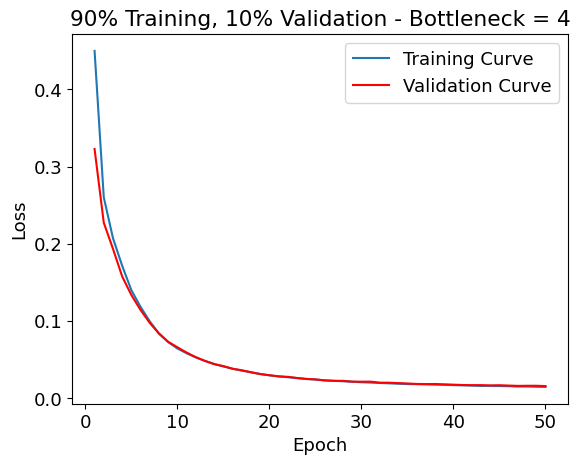

In [42]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Bottleneck = 4")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.savefig("Loss_Curves_b4.png",dpi=300)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


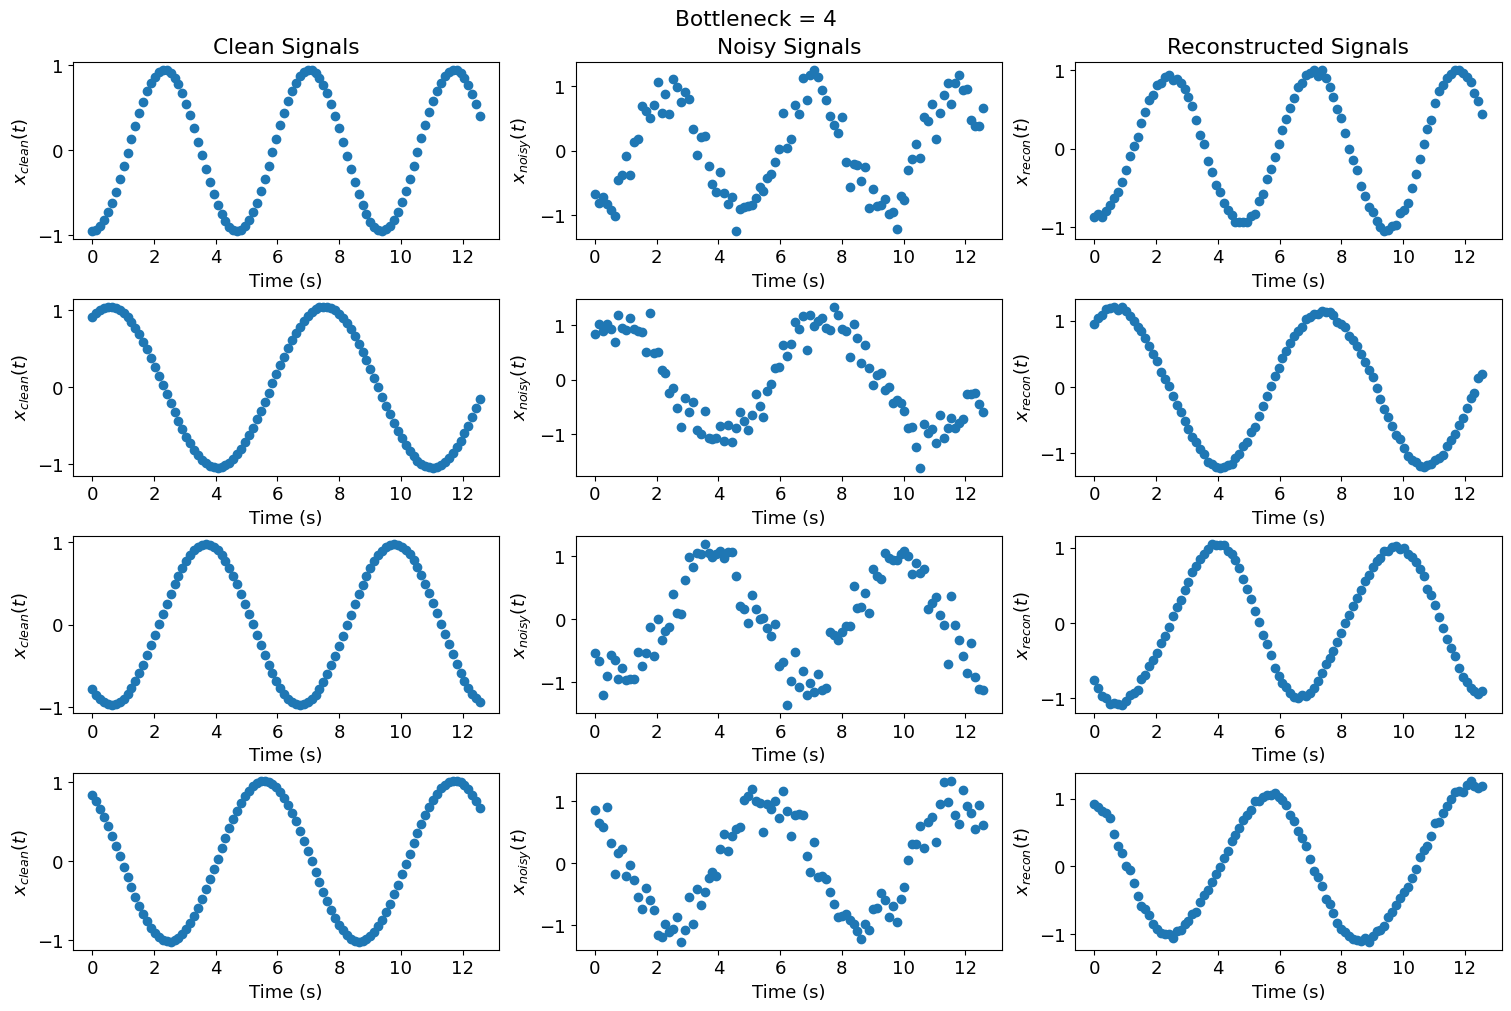

In [43]:
examples = [0, 1, 2, 3]

reconstructed_y = autoencoder.predict(x_val[examples]) # Returns shape (4, 100)
# plot clean vs noisy examples
fig, axes = plt.subplots(4, 3, figsize=(15, 10),constrained_layout=True)
for i, idx in enumerate(examples):
    axes[i,0].scatter(t,y_val[idx]) #clean
    axes[i,1].scatter(t,x_val[idx]) #noisy
    axes[i,2].scatter(t,reconstructed_y[idx]) #reconstructed
axes[0,0].set_title("Clean Signals")
axes[0,1].set_title("Noisy Signals")
axes[0,2].set_title("Reconstructed Signals")
fig.suptitle('Bottleneck = 4')
for i in range(4):
    axes[i,0].set_ylabel(r"$x_{clean}(t)$")
    axes[i,1].set_ylabel(r"$x_{noisy}(t)$")
    axes[i,2].set_ylabel(r"$x_{recon}(t)$")
    
    axes[i,0].set_xlabel("Time (s)")
    axes[i,1].set_xlabel("Time (s)")
    axes[i,2].set_xlabel("Time (s)")

plt.savefig("reconstruct_b4.png",dpi=300)
plt.show()

In [44]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(3, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 3)              │           195 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,415 (52.40 KB)

 Trainable params: 13,415 (52.40 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4612 - val_loss: 0.3646
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3133 - val_loss: 0.2889
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2571 - val_loss: 0.2367
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2159 - val_loss: 0.2126
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1996 - val_loss: 0.1955
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1873 - val_loss: 0.1825
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1762 - val_loss: 0.1695
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1653 - val_loss: 0.1579
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1539 - val_loss: 0.1482
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1446 - val_loss: 0.1402
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1349 - val_loss: 0.1328
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1273 - val_lo

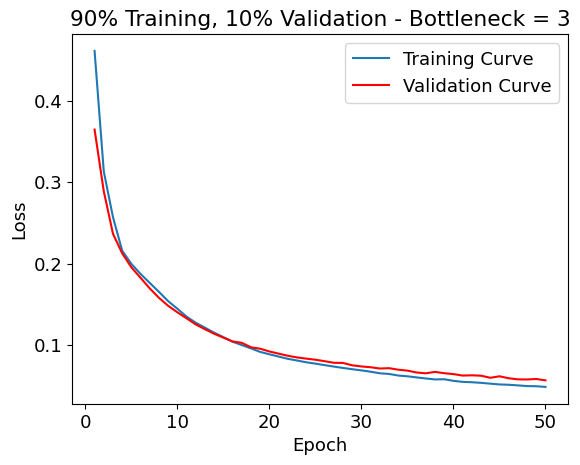

In [46]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Bottleneck = 3")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.savefig("Loss_Curves_b3.png",dpi=300)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


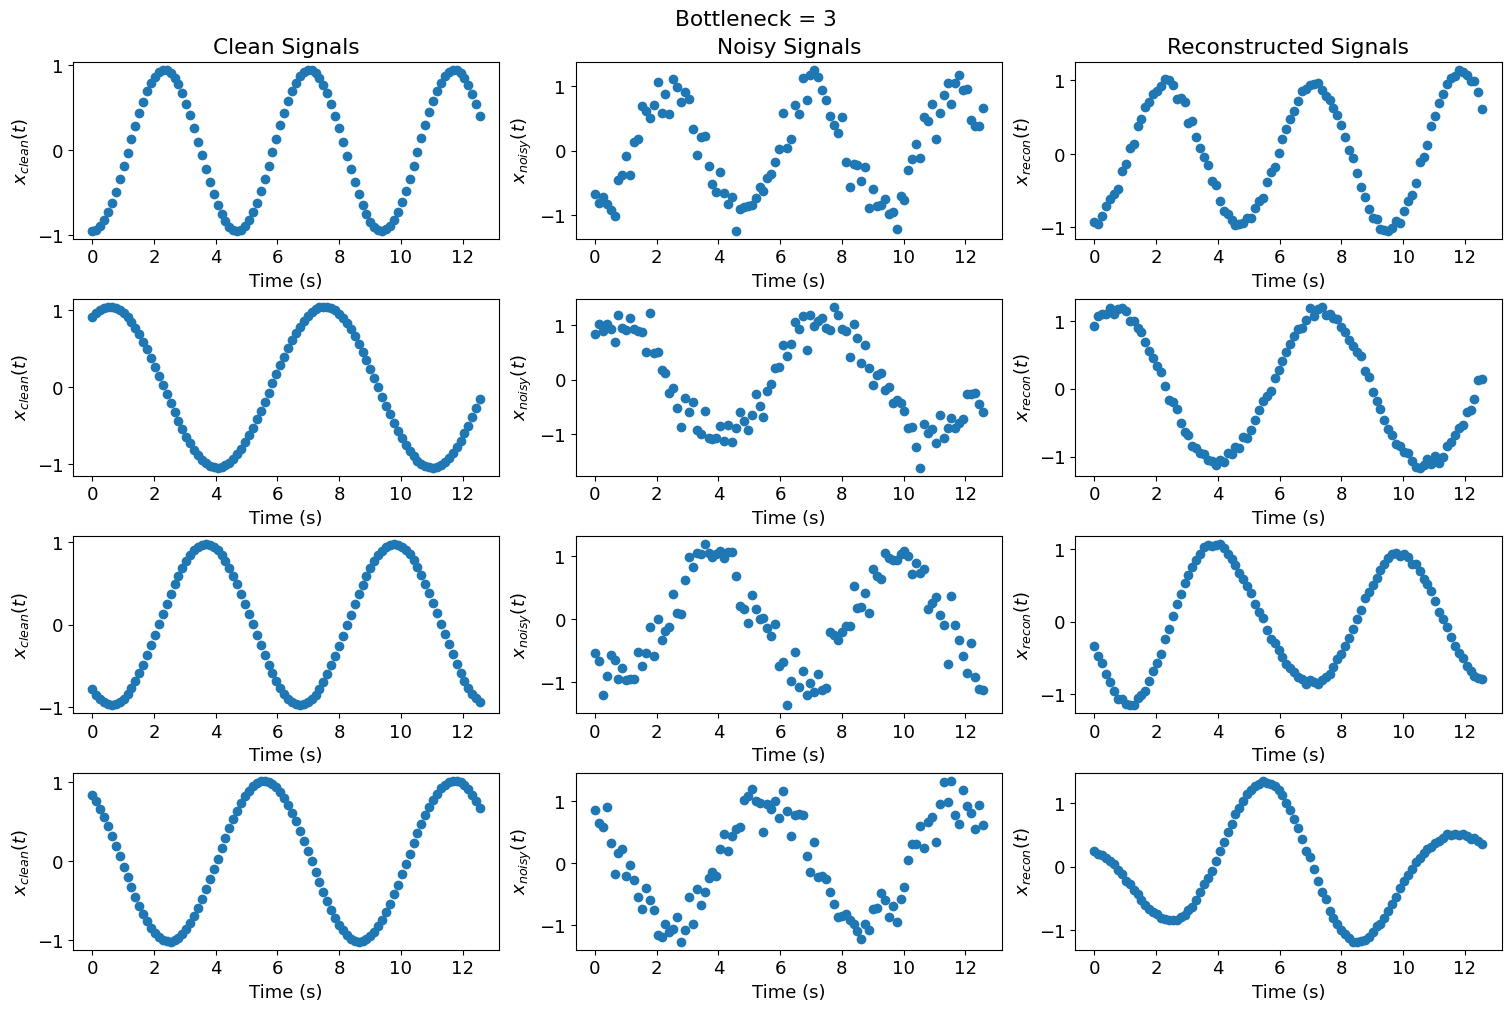

In [47]:
examples = [0, 1, 2, 3]

reconstructed_y = autoencoder.predict(x_val[examples]) # Returns shape (4, 100)
# plot clean vs noisy examples
fig, axes = plt.subplots(4, 3, figsize=(15, 10),constrained_layout=True)
for i, idx in enumerate(examples):
    axes[i,0].scatter(t,y_val[idx]) #clean
    axes[i,1].scatter(t,x_val[idx]) #noisy
    axes[i,2].scatter(t,reconstructed_y[idx]) #reconstructed
axes[0,0].set_title("Clean Signals")
axes[0,1].set_title("Noisy Signals")
axes[0,2].set_title("Reconstructed Signals")
fig.suptitle('Bottleneck = 3')

for i in range(4):
    axes[i,0].set_ylabel(r"$x_{clean}(t)$")
    axes[i,1].set_ylabel(r"$x_{noisy}(t)$")
    axes[i,2].set_ylabel(r"$x_{recon}(t)$")
    
    axes[i,0].set_xlabel("Time (s)")
    axes[i,1].set_xlabel("Time (s)")
    axes[i,2].set_xlabel("Time (s)")

plt.savefig("reconstruct_b3.png",dpi=300)
plt.show()

In [48]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(2, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_44 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 2)              │           130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,286 (51.90 KB)

 Trainable params: 13,286 (51.90 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4734 - val_loss: 0.4171
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3952 - val_loss: 0.3817
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3730 - val_loss: 0.3683
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3594 - val_loss: 0.3536
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3409 - val_loss: 0.3348
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3232 - val_loss: 0.3175
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3064 - val_loss: 0.3003
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2926 - val_loss: 0.2860
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2813 - val_loss: 0.2757
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2728 - val_loss: 0.2681
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2656 - val_loss: 0.2622
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2598 - val_lo

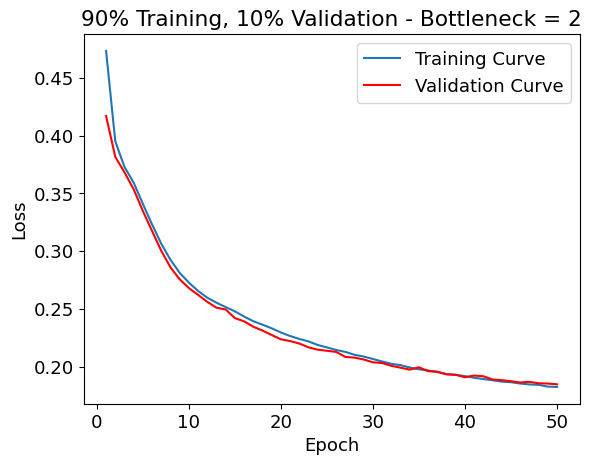

In [50]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Bottleneck = 2")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.savefig("Loss_Curves_b2.png",dpi=300)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


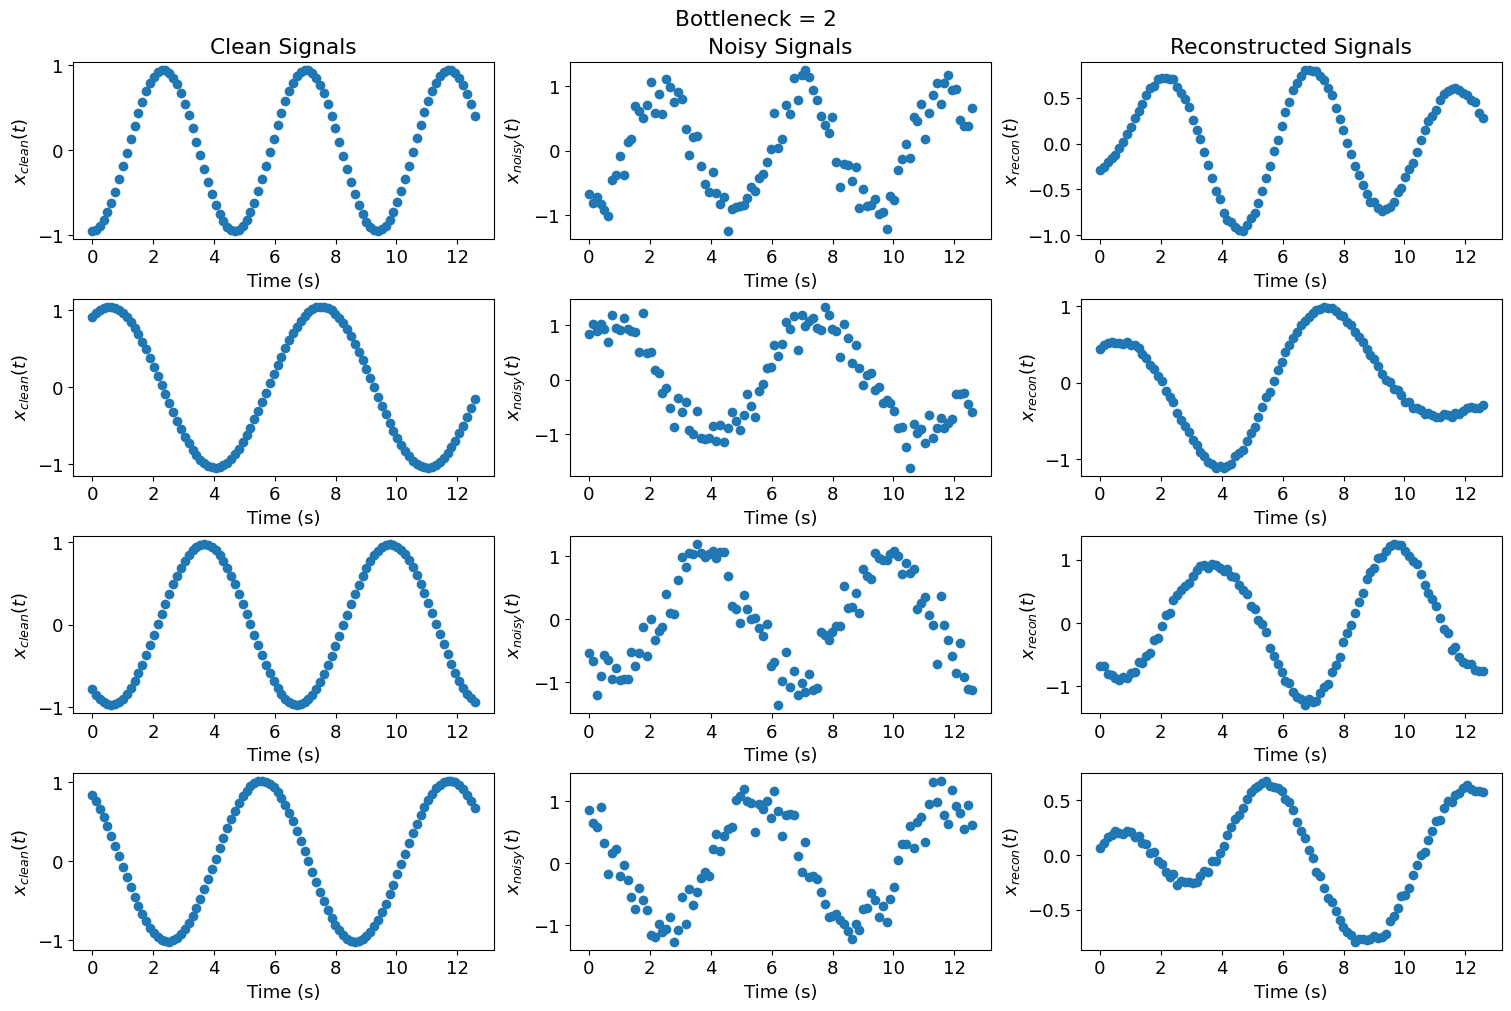

In [51]:
examples = [0, 1, 2, 3]

reconstructed_y = autoencoder.predict(x_val[examples]) # Returns shape (4, 100)
# plot clean vs noisy examples
fig, axes = plt.subplots(4, 3, figsize=(15, 10),constrained_layout=True)
for i, idx in enumerate(examples):
    axes[i,0].scatter(t,y_val[idx]) #clean
    axes[i,1].scatter(t,x_val[idx]) #noisy
    axes[i,2].scatter(t,reconstructed_y[idx]) #reconstructed
axes[0,0].set_title("Clean Signals")
axes[0,1].set_title("Noisy Signals")
axes[0,2].set_title("Reconstructed Signals")
fig.suptitle('Bottleneck = 2')
for i in range(4):
    axes[i,0].set_ylabel(r"$x_{clean}(t)$")
    axes[i,1].set_ylabel(r"$x_{noisy}(t)$")
    axes[i,2].set_ylabel(r"$x_{recon}(t)$")
    
    axes[i,0].set_xlabel("Time (s)")
    axes[i,1].set_xlabel("Time (s)")
    axes[i,2].set_xlabel("Time (s)")

plt.savefig("reconstruct_b2.png",dpi=300)
plt.show()

In [52]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(1, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,157 (51.39 KB)

 Trainable params: 13,157 (51.39 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5127 - val_loss: 0.4905
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4867 - val_loss: 0.4819
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4791 - val_loss: 0.4758
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4737 - val_loss: 0.4712
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4689 - val_loss: 0.4668
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4632 - val_loss: 0.4606
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4569 - val_loss: 0.4535
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4511 - val_loss: 0.4488
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4470 - val_loss: 0.4456
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4444 - val_loss: 0.4433
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4420 - val_loss: 0.4418
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4409 - val_lo

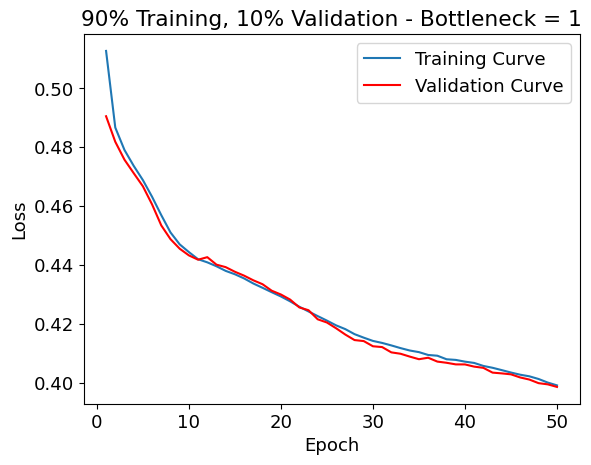

In [54]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Bottleneck = 1")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.savefig("Loss_Curves_b1.png",dpi=300)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


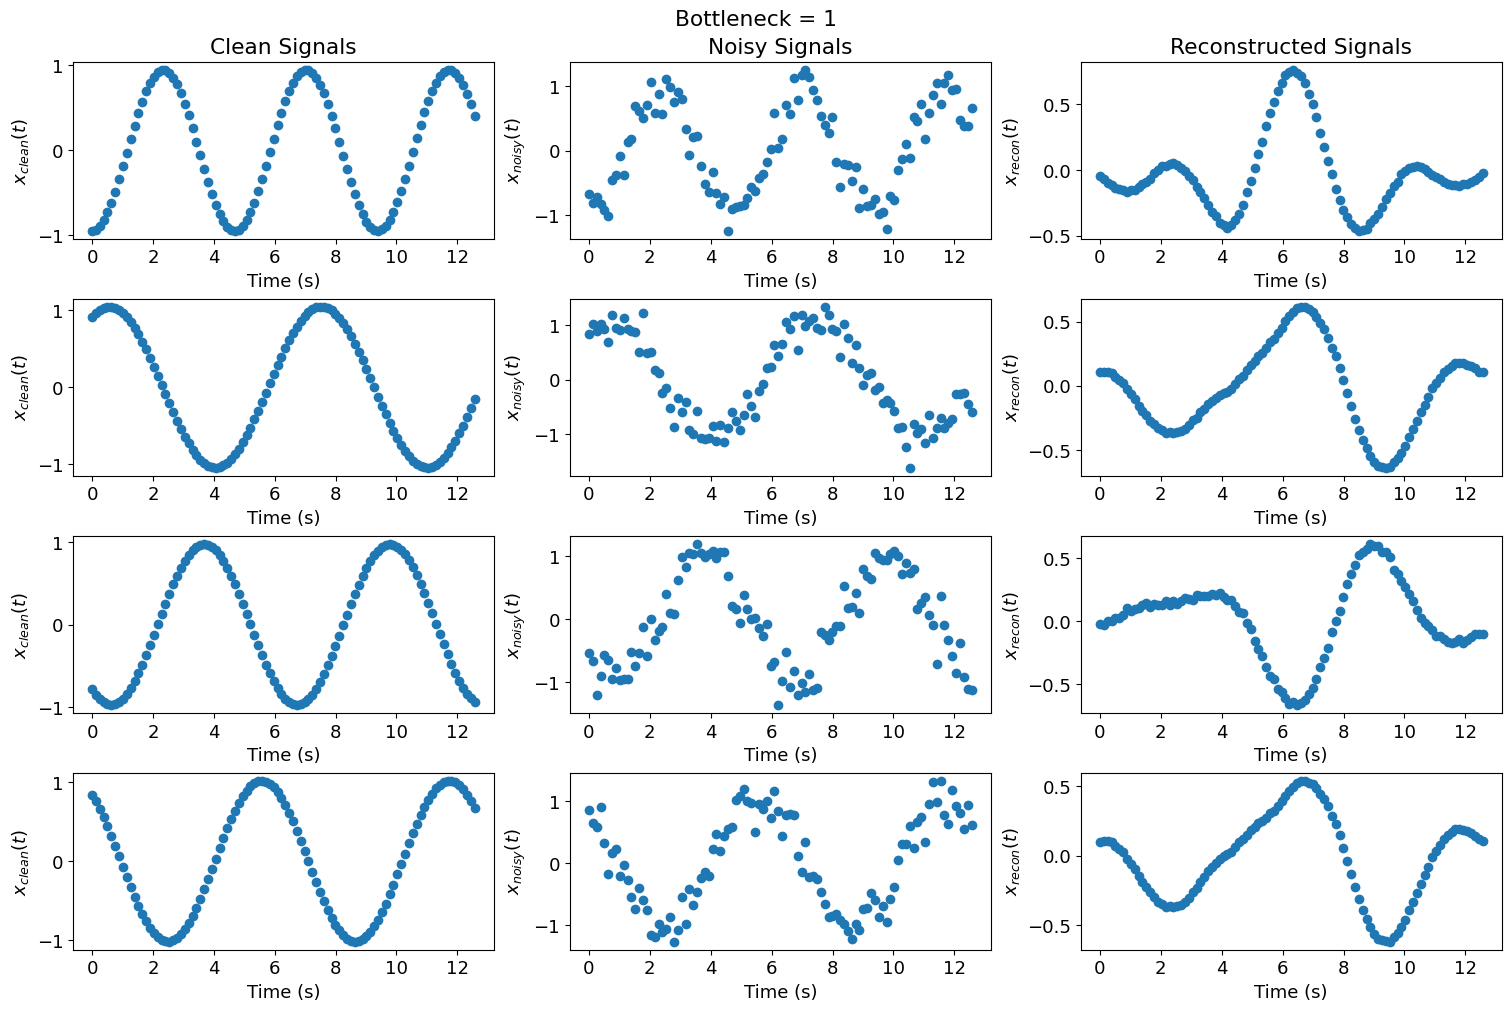

In [55]:
examples = [0, 1, 2, 3]

reconstructed_y = autoencoder.predict(x_val[examples]) # Returns shape (4, 100)
# plot clean vs noisy examples
fig, axes = plt.subplots(4, 3, figsize=(15, 10),constrained_layout=True)
for i, idx in enumerate(examples):
    axes[i,0].scatter(t,y_val[idx]) #clean
    axes[i,1].scatter(t,x_val[idx]) #noisy
    axes[i,2].scatter(t,reconstructed_y[idx]) #reconstructed
axes[0,0].set_title("Clean Signals")
axes[0,1].set_title("Noisy Signals")
axes[0,2].set_title("Reconstructed Signals")
fig.suptitle('Bottleneck = 1')
for i in range(4):
    axes[i,0].set_ylabel(r"$x_{clean}(t)$")
    axes[i,1].set_ylabel(r"$x_{noisy}(t)$")
    axes[i,2].set_ylabel(r"$x_{recon}(t)$")
    
    axes[i,0].set_xlabel("Time (s)")
    axes[i,1].set_xlabel("Time (s)")
    axes[i,2].set_xlabel("Time (s)")

plt.savefig("reconstruct_b1.png",dpi=300)
plt.show()

## Noise models
Instead of Gaussian noise, test Laplace noise.

In [56]:
# generate dataset
num_curve=10000
A = np.random.uniform(0.5,1.5,size=(num_curve,1))
w = np.random.uniform(0.5,2,size=(num_curve,1))
phi = np.random.uniform(0,2*np.pi,size=(num_curve,1))

N = 100
t = np.linspace(0,4*np.pi,100)

clean_curve = A*np.sin(w*t + phi)
clean_curve.shape

(10000, 100)

In [57]:
# generate noisy data - Laplace
sigma = 0.2
err = np.random.laplace(loc=0, scale=sigma, size=clean_curve.shape)

noisy_curve = clean_curve + err
noisy_curve.shape

(10000, 100)

In [58]:
# dataset split
#get a different index for different sine curves
idx = np.random.permutation(num_curve) #this will shuffle through different indices
training_size = int(num_curve*0.9) #90% training - must be integer for indexing
train_idx = idx[:training_size] #the 90% training set
#train_idx.shape
val_idx = idx[training_size:] #the remaning 1000 (10%)
#val_idx.shape

#input
x_train = noisy_curve[train_idx]
x_val = noisy_curve[val_idx]

#target
y_train = clean_curve[train_idx]
y_val = clean_curve[val_idx]

In [59]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(16, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_52 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,092 (58.95 KB)

 Trainable params: 15,092 (58.95 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
start = time.time()
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)
print(f"Elapsed: {time.time() - start:.4f} seconds")
# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3636 - val_loss: 0.1236
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0633 - val_loss: 0.0364
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0273 - val_loss: 0.0231
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0204 - val_loss: 0.0196
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0174 - val_loss: 0.0164
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0150 - val_loss: 0.0145
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0131 - val_loss: 0.0128
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0117 - val_loss: 0.0118
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0107 - val_loss: 0.0109
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0100 - val_loss: 0.0102
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0095 - val_loss: 0.0097
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0091 - val_lo

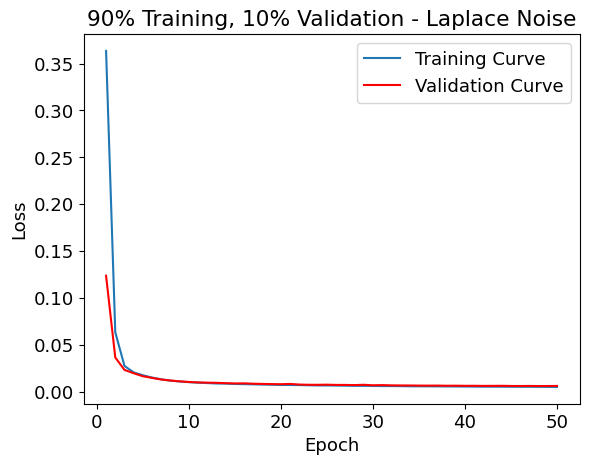

In [61]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Laplace Noise")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.savefig("Loss_Curves_Laplace.png",dpi=300)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


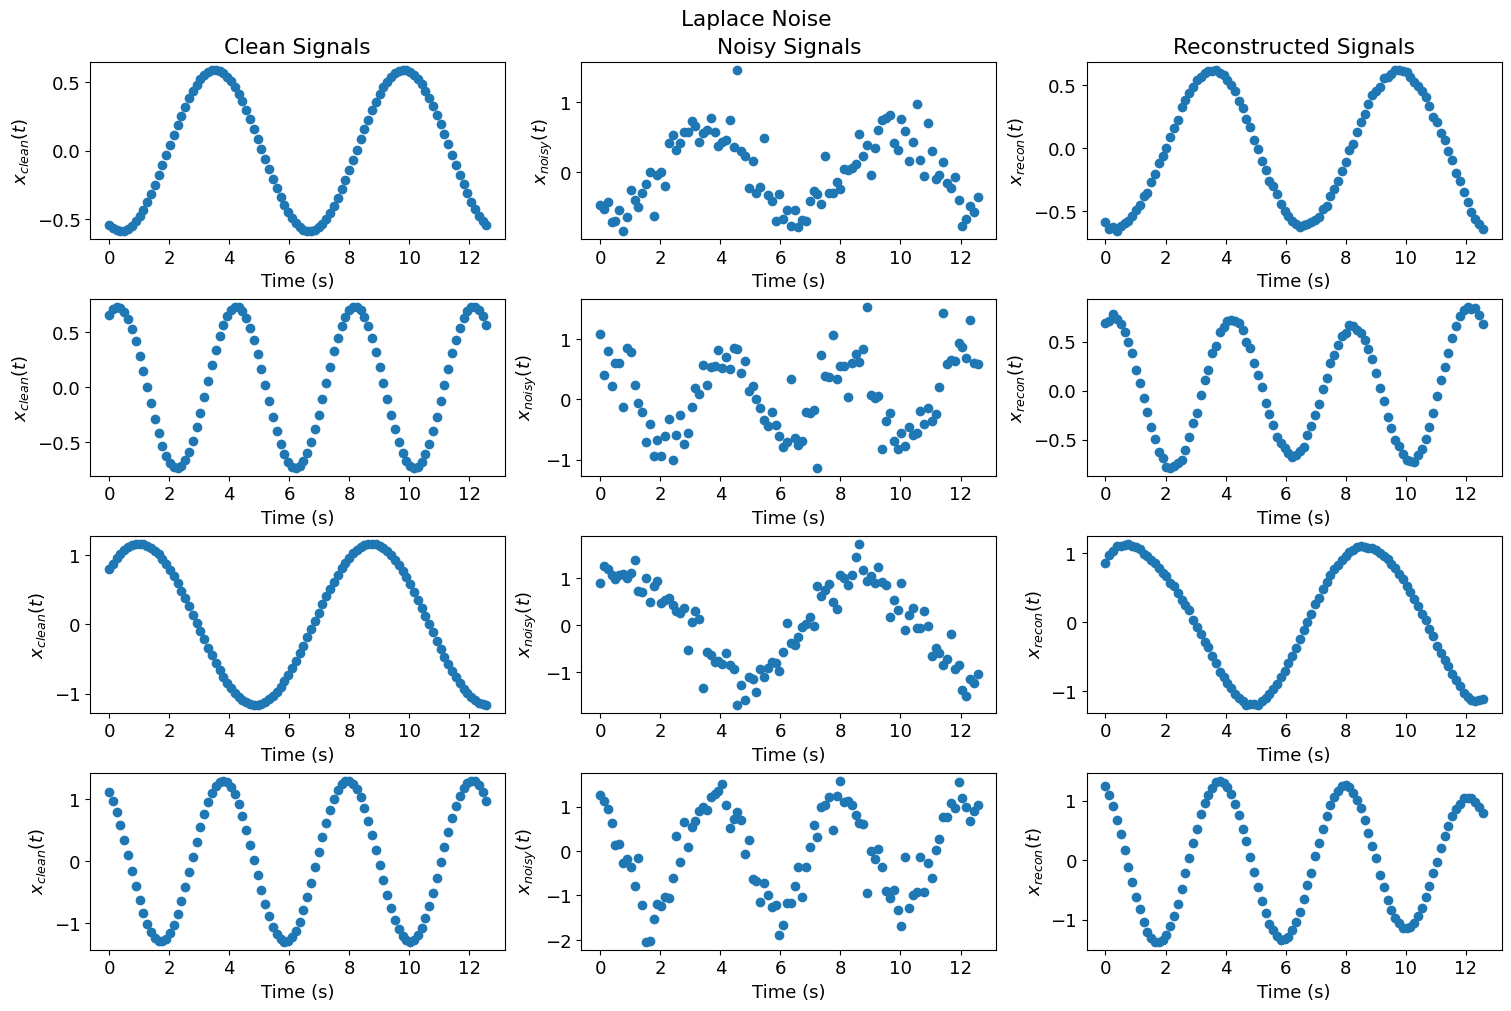

In [62]:
examples = [0, 1, 2, 3]

reconstructed_y = autoencoder.predict(x_val[examples]) # Returns shape (4, 100)

# plot clean vs noisy examples
fig, axes = plt.subplots(4, 3, figsize=(15, 10),constrained_layout=True)
for i, idx in enumerate(examples):
    axes[i,0].scatter(t,y_val[idx]) #clean
    axes[i,1].scatter(t,x_val[idx]) #noisy
    axes[i,2].scatter(t,reconstructed_y[idx]) #reconstructed
axes[0,0].set_title("Clean Signals")
axes[0,1].set_title("Noisy Signals")
axes[0,2].set_title("Reconstructed Signals")
fig.suptitle("Laplace Noise")
for i in range(4):
    axes[i,0].set_ylabel(r"$x_{clean}(t)$")
    axes[i,1].set_ylabel(r"$x_{noisy}(t)$")
    axes[i,2].set_ylabel(r"$x_{recon}(t)$")
    
    axes[i,0].set_xlabel("Time (s)")
    axes[i,1].set_xlabel("Time (s)")
    axes[i,2].set_xlabel("Time (s)")

plt.savefig("Reconstruct_Laplace.png",dpi=300)
plt.show()